In [5]:
from pathlib import Path
import pandas as pd
import sys

In [6]:
# ==================================================
# RUTAS
# ==================================================

BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_RAW = (
    BASE
    / "01_data"
    / "01_raw"
    / "rrss"
    / "youtube"
)

RUTA_PROCESADOS = (
    BASE
    / "01_data"
    / "02_processed"
    / "rrss"
    / "youtube"
)

RUTA_TABLAS_INTEGRADO = (
    BASE
    / "03_outputs"
    / "tables"
    / "analisis_integrado"
)

RUTA_PROCESADOS.mkdir(
    parents=True,
    exist_ok=True
)

print("RAW:", RUTA_RAW)
print("PROCESADOS:", RUTA_PROCESADOS)

RAW: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\01_raw\rrss\youtube
PROCESADOS: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\rrss\youtube


In [7]:
df_2015_inm = pd.read_csv(
    RUTA_RAW / "youtube_inmigracion_2015_comentarios.csv"
)

df_2016_inm = pd.read_csv(
    RUTA_RAW / "youtube_inmigracion_2016_comentarios.csv"
)

df_2019_inm = pd.read_csv(
    RUTA_RAW / "youtube_inmigracion_2019_ampliado.csv"
)

df_2023_inm = pd.read_csv(
    RUTA_RAW / "youtube_inmigracion_2023_comentarios.csv"
)

df_2015_lgtbi = pd.read_csv(
    RUTA_RAW / "youtube_lgtbi_2015_comentarios.csv"
)

df_2016_lgtbi = pd.read_csv(
    RUTA_RAW / "youtube_lgtbi_2016_comentarios.csv"
)

df_2019_lgtbi = pd.read_csv(
    RUTA_RAW / "youtube_lgtbi_2019_comentarios.csv"
)

df_2023_lgtbi = pd.read_csv(
    RUTA_RAW / "youtube_lgtbi_2023_comentarios.csv"
)

In [8]:
print(df_2015_inm.shape)
print(df_2016_inm.shape)
print(df_2019_inm.shape)
print(df_2023_inm.shape)

print(df_2015_lgtbi.shape)
print(df_2016_lgtbi.shape)
print(df_2019_lgtbi.shape)
print(df_2023_lgtbi.shape)

(817, 10)
(2084, 10)
(20151, 10)
(7539, 10)
(2828, 10)
(4791, 10)
(6469, 10)
(5642, 10)


# Unimos en un solo dataframe

In [9]:
df_youtube = pd.concat(
    [
        df_2015_inm,
        df_2016_inm,
        df_2019_inm,
        df_2023_inm,
        df_2015_lgtbi,
        df_2016_lgtbi,
        df_2019_lgtbi,
        df_2023_lgtbi
    ],
    ignore_index=True
)

df_youtube.shape

(50321, 10)

In [10]:
print(
    sorted(
        df_youtube["año_video"]
        .dropna()
        .astype(int)
        .unique()
    )
)

[np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]


In [174]:
df_youtube.groupby(
    ["tema", "año_video"]
).size()

tema         año_video
inmigracion  2015           817
             2016          2084
             2019         20151
             2023          7539
lgtbi        2015          2828
             2016          4791
             2019          6469
             2023          5642
dtype: int64

In [175]:
print(df_youtube.columns)

print("\nNulos:")
print(df_youtube.isna().sum())

print("\nDuplicados completos:")
print(df_youtube.duplicated().sum())

Index(['video_id', 'autor', 'fecha', 'likes', 'texto', 'titulo_video', 'canal',
       'fecha_video', 'año_video', 'tema'],
      dtype='object')

Nulos:
video_id        0
autor           0
fecha           0
likes           0
texto           1
titulo_video    0
canal           0
fecha_video     0
año_video       0
tema            0
dtype: int64

Duplicados completos:
6


In [176]:
df_youtube.duplicated(
    subset=["video_id", "texto"]
).sum()

np.int64(1033)

# Limpieza

In [177]:
df_youtube = df_youtube.dropna(
    subset=["texto"]
)

df_youtube = df_youtube.drop_duplicates()

df_youtube = df_youtube.drop_duplicates(
    subset=["video_id", "texto"]
)

df_youtube.shape

(49287, 10)

In [178]:
df_youtube["tema"].value_counts()

tema
inmigracion    30469
lgtbi          18818
Name: count, dtype: int64

In [179]:
df_youtube["año_video"].value_counts().sort_index()

año_video
2015     3574
2016     6838
2019    25901
2023    12974
Name: count, dtype: int64

In [180]:
df_youtube.to_csv(
    RUTA_PROCESADOS / "youtube_comentarios_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

In [181]:
df_youtube["texto"].str.len().describe()

count    49287.000000
mean       114.028588
std        203.666644
min          1.000000
25%         30.000000
50%         62.000000
75%        125.000000
max       8994.000000
Name: texto, dtype: float64

In [182]:
df_youtube["texto"].str.split().str.len().describe()

count    49287.000000
mean        20.442632
std         35.650583
min          1.000000
25%          5.000000
50%         11.000000
75%         23.000000
max       1429.000000
Name: texto, dtype: float64

# Clasificación

In [ ]:
RUTA_DICCIONARIOS = (
    BASE
    / "scripts"
    / "diccionarios"
)

if str(RUTA_DICCIONARIOS) not in sys.path:
    sys.path.append(str(RUTA_DICCIONARIOS))

from diccionario_terminos import analizar_articulo_completo

In [184]:
resultados = df_youtube["texto"].apply(
    analizar_articulo_completo
)

df_resultados = pd.DataFrame(
    resultados.tolist(),
    index=df_youtube.index
)

df_youtube_clasificado = pd.concat(
    [df_youtube, df_resultados],
    axis=1
)

df_youtube_clasificado.shape

(49287, 22)

In [185]:
df_youtube_clasificado["nivel_xenofobia"].value_counts()

nivel_xenofobia
sin_mencion                 46691
neutro                       2004
hostilidad_explicita          302
marco_conflictivo             289
violencia_discriminacion        1
Name: count, dtype: int64

In [186]:
df_youtube_clasificado["nivel_lgtbifobia"].value_counts()

nivel_lgtbifobia
sin_mencion                 47462
neutro                       1713
marco_conflictivo              63
hostilidad_explicita           38
violencia_discriminacion       11
Name: count, dtype: int64

In [187]:
df_youtube_clasificado[
    df_youtube_clasificado["nivel_xenofobia"] == "hostilidad_explicita"
][["texto"]].sample(20, random_state=42)

,texto
17405,Creo que el video es muy claro pero con una in...
22719,"Pueden amar u odiar a Trump, pero deben admiti..."
9797,Una furiosa multitud de alrededor de 500 inmig...
25293,3 miliones extranjeros españoles viven la fuer...
5227,Una responsable de impulsar estas políticas de...
1976,"Como diría Recio Matamoros :""ostia terrrrrribl..."
9975,"""estamos en contra de la inmigración ilegal""\n..."
22497,"Esta historia me recuerda que acá en Chile, en..."
27057,"Chamo eso será en Venezuela, en Cuba si es pos..."
4303,Inmigrates ilegales crack no los legales


In [188]:
df_youtube_clasificado[
    df_youtube_clasificado["nivel_lgtbifobia"] == "hostilidad_explicita"
][["texto"]].sample(20, random_state=42)

,texto
46084,Q aberración q locura. El kiosko d la muerte e...
50286,Que? No pedimos que pongan nuestros colores en...
16031,Pues yo rechazo a esos de la lista y a los pol...
36700,"Madre mía, yo estuve en Italia y ligue una pas..."
45328,"Es una aberración ante los ojos de Dios, pero ..."
40323,Pues Sara es una mujer bella al igual que la o...
20939,Hipócritas como van a tener hijos sin empleo...
40326,Aberración es ser tan fascista señor.
40289,"El problema es la educación, estos temas han s..."
37947,"Yo si mi hijo me dice que es gay , que haga su..."


In [189]:
df_youtube_clasificado[
    df_youtube_clasificado["nivel_xenofobia"] == "sin_mencion"
][["texto"]].sample(50, random_state=42)

,texto
42422,Más allá de las corazas y vestuarios y... piel...
8724,"Vaya discurso más terrorifico, lleno de mentir..."
43755,"Todabia hay gente decente en Europa, Hungría, ..."
43809,HEROES DE LA PATRIA
50259,El one piece
34671,No me gustó
18399,"Respecto a los bots (diria de Steve Bannon, pe..."
37601,1:58 opino lo mismo que el señor👍
31247,Itok
32461,Es demasiado ridiculo el odio hacia parejas de...


Con el mismo diccionario que usamos para prensa es insuficiente, ya que el lenguaje que se usa en comentarios y en artículos de prensa son diferentes. Realizo otro específico para RRSS

In [190]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=20
)

X = vectorizer.fit_transform(
    df_youtube["texto"].fillna("")
)

frecuencias = pd.DataFrame({
    "termino": vectorizer.get_feature_names_out(),
    "frecuencia": X.sum(axis=0).A1
})

frecuencias = frecuencias.sort_values(
    "frecuencia",
    ascending=False
)

frecuencias.head(500)

,termino,frecuencia
5831,que,40120
1300,de,36247
3549,la,24163
4784,no,20629
1914,el,18202
...,...,...
2145,en este,288
5243,pasar,288
6490,sean,287
3625,la homosexualidad,286


Comenatarios sobre inmigración

In [191]:
df_inm = df_youtube[
    df_youtube["tema"] == "inmigracion"
]

In [192]:
vectorizer = CountVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=10
)

X = vectorizer.fit_transform(
    df_inm["texto"].fillna("")
)

top_inm = pd.DataFrame({
    "termino": vectorizer.get_feature_names_out(),
    "frecuencia": X.sum(axis=0).A1
})

top_inm = top_inm.sort_values(
    "frecuencia",
    ascending=False
)

top_inm.head(500)

,termino,frecuencia
8329,que,26967
1859,de,25724
5115,la,16213
6835,no,13447
3036,en,13034
...,...,...
9168,se lo,196
9837,sé,196
11105,vox es,195
3902,euros,195


In [193]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stopwords_es = stopwords.words("spanish")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\herre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [194]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

stopwords_es = stopwords.words("spanish")

stopwords_extra = [
    "si", "sí", "ser", "hacer", "dice", "dijo",
    "video", "youtube", "canal", "años", "año",
    "gracias", "gente"
]

stopwords_total = list(set(stopwords_es + stopwords_extra))

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=stopwords_total,
    ngram_range=(1,2),
    min_df=10
)

X = vectorizer.fit_transform(
    df_inm["texto"].fillna("")
)

top_inm = pd.DataFrame({
    "termino": vectorizer.get_feature_names_out(),
    "frecuencia": X.sum(axis=0).A1
}).sort_values(
    "frecuencia",
    ascending=False
)

top_inm.head(100)

,termino,frecuencia
1800,españa,6097
5348,vox,4777
5253,viva,2752
1854,españoles,2098
88,abascal,1909
...,...,...
1245,cómo,378
261,alguien,373
3249,muchas,367
3638,parte,364


In [195]:
patron_xeno = (
    r"moro|moros|mena|menas|ilegal|ilegales|"
    r"invasion|invasión|invaden|sustitucion|sustitución|"
    r"reemplazo|islam|musulman|musulmán|musulmanes|"
    r"deport|expuls|paguita|frontera|patera|cayuco|"
    r"marroqui|marroquí|africano|africanos"
)

candidatos_xeno = top_inm[
    top_inm["termino"].str.contains(
        patron_xeno,
        case=False,
        regex=True,
        na=False
    )
].sort_values(
    "frecuencia",
    ascending=False
)

candidatos_xeno.head(100)

,termino,frecuencia
3291,musulmanes,283
2503,ilegal,272
2504,ilegales,232
3097,menas,213
2121,frontera,146
2668,islam,143
2123,fronteras,140
3096,mena,113
3020,marroquíes,104
211,africanos,98


Comentarios LGTBI

In [196]:
df_lgtbi = df_youtube[
    df_youtube["tema"] == "lgtbi"
]

In [197]:
vectorizer = CountVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=10
)

X = vectorizer.fit_transform(
    df_lgtbi["texto"].fillna("")
)

top_lgtbi = pd.DataFrame({
    "termino": vectorizer.get_feature_names_out(),
    "frecuencia": X.sum(axis=0).A1
})

top_lgtbi = top_lgtbi.sort_values(
    "frecuencia",
    ascending=False
)

top_lgtbi.head(500)

,termino,frecuencia
4110,que,13153
963,de,10523
2560,la,7950
3410,no,7182
1393,el,6167
...,...,...
3972,por lo,100
2245,haya,100
3039,matrimonio,99
951,dar,99


In [198]:
vectorizer_lgtbi = CountVectorizer(
    lowercase=True,
    stop_words=stopwords_total,
    ngram_range=(1, 2),
    min_df=10
)

X_lgtbi = vectorizer_lgtbi.fit_transform(
    df_lgtbi["texto"].fillna("")
)

top_lgtbi = pd.DataFrame({
    "termino": vectorizer_lgtbi.get_feature_names_out(),
    "frecuencia": X_lgtbi.sum(axis=0).A1
}).sort_values(
    "frecuencia",
    ascending=False
)

In [199]:
patron_lgtbi = (
    r"gay|gays|homosexual|homosexuales|lesbiana|lesbianas|"
    r"trans|transexual|travelo|travesti|maricon|maricón|"
    r"bollera|homofobia|transfobia|aberracion|aberración|"
    r"degenerado|degenerados|enfermedad|contra natura|"
    r"adoctrinamiento|ideologia de genero|ideología de género|"
    r"agenda lgtb|agenda woke"
)

candidatos_lgtbi = top_lgtbi[
    top_lgtbi["termino"].str.contains(
        patron_lgtbi,
        case=False,
        regex=True,
        na=False
    )
].sort_values(
    "frecuencia",
    ascending=False
)

candidatos_lgtbi.head(100)

,termino,frecuencia
1093,gay,743
1255,homosexual,429
1257,homosexuales,353
1258,homosexualidad,321
1095,gays,196
1247,homofobia,180
2590,trans,145
1477,lesbiana,113
1478,lesbianas,63
911,enfermedad,46


In [200]:
from diccionario_rrss import analizar_comentario_rrss

resultados = df_youtube["texto"].apply(
    analizar_comentario_rrss
)

df_rrss = pd.concat(
    [
        df_youtube.reset_index(drop=True),
        pd.DataFrame(resultados.tolist())
    ],
    axis=1
)

df_rrss.shape

(49287, 22)

In [201]:
df_rrss["nivel_xenofobia_rrss"].value_counts()

nivel_xenofobia_rrss
sin_mencion                 45600
neutro                       2545
marco_conflictivo             936
hostilidad_explicita          205
violencia_discriminacion        1
Name: count, dtype: int64

In [202]:
df_rrss["nivel_lgtbifobia_rrss"].value_counts()

nivel_lgtbifobia_rrss
sin_mencion                 46458
neutro                       2490
violencia_discriminacion      197
marco_conflictivo              82
hostilidad_explicita           60
Name: count, dtype: int64

In [203]:
# ==================================================
# MUESTRA MANUAL DE COMENTARIOS "SIN_MENCION"
# ==================================================

# Inmigración: 250 comentarios sin mención xenófoba
muestra_inm = df_rrss[
    (df_rrss["tema"] == "inmigracion") &
    (df_rrss["nivel_xenofobia_rrss"] == "sin_mencion")
].sample(
    n=250,
    random_state=42
).copy()

muestra_inm["categoria_revision"] = "inmigracion"


# LGTBI: 250 comentarios sin mención LGTBIfóbica
muestra_lgtbi = df_rrss[
    (df_rrss["tema"] == "lgtbi") &
    (df_rrss["nivel_lgtbifobia_rrss"] == "sin_mencion")
].sample(
    n=250,
    random_state=42
).copy()

muestra_lgtbi["categoria_revision"] = "lgtbi"


# Unir las dos muestras
muestra_revision = pd.concat(
    [muestra_inm, muestra_lgtbi],
    ignore_index=True
)


# Columnas vacías para completar manualmente
muestra_revision["nivel_manual"] = ""
muestra_revision["expresion_detectada"] = ""
muestra_revision["observaciones"] = ""


# Seleccionar solo las columnas útiles para revisar
columnas_revision = [
    "categoria_revision",
    "año_video",
    "canal",
    "titulo_video",
    "texto",
    "nivel_manual",
    "expresion_detectada",
    "observaciones"
]

muestra_revision = muestra_revision[columnas_revision]


# Guardar en CSV
muestra_revision.to_csv(
    RUTA_PROCESADOS / "muestra_500_sin_mencion_revision_manual.csv",
    index=False,
    encoding="utf-8-sig"
)

print(muestra_revision.shape)
print("Archivo guardado correctamente")

(500, 8)
Archivo guardado correctamente


In [204]:
import numpy as np

df_rrss["nivel_discurso"] = np.where(
    df_rrss["tema"] == "inmigracion",
    df_rrss["nivel_xenofobia_rrss"],
    df_rrss["nivel_lgtbifobia_rrss"]
)

In [205]:
tabla_absolutos = (
    df_rrss
    .groupby(
        ["tema", "año_video", "nivel_discurso"]
    )
    .size()
    .reset_index(name="comentarios")
)

tabla_absolutos

,tema,año_video,nivel_discurso,comentarios
0,inmigracion,2015,hostilidad_explicita,19
1,inmigracion,2015,marco_conflictivo,7
2,inmigracion,2015,neutro,226
3,inmigracion,2015,sin_mencion,564
4,inmigracion,2016,hostilidad_explicita,10
5,inmigracion,2016,marco_conflictivo,19
6,inmigracion,2016,neutro,174
7,inmigracion,2016,sin_mencion,1870
8,inmigracion,2019,hostilidad_explicita,109
9,inmigracion,2019,marco_conflictivo,750


In [206]:
tabla_porcentajes = tabla_absolutos.copy()

tabla_porcentajes["porcentaje"] = (
    tabla_porcentajes["comentarios"]
    / tabla_porcentajes.groupby(
        ["tema", "año_video"]
    )["comentarios"].transform("sum")
    * 100
).round(2)

tabla_porcentajes

,tema,año_video,nivel_discurso,comentarios,porcentaje
0,inmigracion,2015,hostilidad_explicita,19,2.33
1,inmigracion,2015,marco_conflictivo,7,0.86
2,inmigracion,2015,neutro,226,27.70
3,inmigracion,2015,sin_mencion,564,69.12
4,inmigracion,2016,hostilidad_explicita,10,0.48
5,inmigracion,2016,marco_conflictivo,19,0.92
6,inmigracion,2016,neutro,174,8.39
7,inmigracion,2016,sin_mencion,1870,90.21
8,inmigracion,2019,hostilidad_explicita,109,0.54
9,inmigracion,2019,marco_conflictivo,750,3.72


In [207]:
pivot_porcentajes = tabla_porcentajes.pivot_table(
    index=["tema", "año_video"],
    columns="nivel_discurso",
    values="porcentaje",
    fill_value=0
).reset_index()

pivot_porcentajes

nivel_discurso,tema,año_video,hostilidad_explicita,marco_conflictivo,neutro,sin_mencion,violencia_discriminacion
0,inmigracion,2015,2.33,0.86,27.70,69.12,0.00
1,inmigracion,2016,0.48,0.92,8.39,90.21,0.00
2,inmigracion,2019,0.54,3.72,6.84,88.90,0.00
3,inmigracion,2023,0.57,1.62,9.70,88.12,0.00
4,lgtbi,2015,0.07,0.36,9.28,88.47,1.81
5,lgtbi,2016,0.17,0.21,15.38,82.77,1.47
6,lgtbi,2019,0.40,0.30,8.62,90.09,0.59
7,lgtbi,2023,0.25,0.34,12.32,86.51,0.58


In [208]:
columnas_ordenadas = [
    "tema",
    "año_video",
    "sin_mencion",
    "neutro",
    "marco_conflictivo",
    "hostilidad_explicita",
    "violencia_discriminacion"
]

for columna in columnas_ordenadas:
    if columna not in pivot_porcentajes.columns:
        pivot_porcentajes[columna] = 0

pivot_porcentajes = pivot_porcentajes[
    columnas_ordenadas
]

pivot_porcentajes

nivel_discurso,tema,año_video,sin_mencion,neutro,marco_conflictivo,hostilidad_explicita,violencia_discriminacion
0,inmigracion,2015,69.12,27.70,0.86,2.33,0.00
1,inmigracion,2016,90.21,8.39,0.92,0.48,0.00
2,inmigracion,2019,88.90,6.84,3.72,0.54,0.00
3,inmigracion,2023,88.12,9.70,1.62,0.57,0.00
4,lgtbi,2015,88.47,9.28,0.36,0.07,1.81
5,lgtbi,2016,82.77,15.38,0.21,0.17,1.47
6,lgtbi,2019,90.09,8.62,0.30,0.40,0.59
7,lgtbi,2023,86.51,12.32,0.34,0.25,0.58


In [209]:
mapa_niveles = {
    "sin_mencion": 1,
    "neutro": 2,
    "marco_conflictivo": 3,
    "hostilidad_explicita": 4,
    "violencia_discriminacion": 5
}

df_rrss["indice_discurso"] = (
    df_rrss["nivel_discurso"]
    .map(mapa_niveles)
)

In [210]:
indice_medio = (
    df_rrss
    .groupby(
        ["tema", "año_video"]
    )["indice_discurso"]
    .mean()
    .round(3)
    .reset_index(name="indice_medio")
)

indice_medio

,tema,año_video,indice_medio
0,inmigracion,2015,1.364
1,inmigracion,2016,1.117
2,inmigracion,2019,1.159
3,inmigracion,2023,1.146
4,lgtbi,2015,1.175
5,lgtbi,2016,1.222
6,lgtbi,2019,1.128
7,lgtbi,2023,1.161


In [211]:
pivot_porcentajes.to_csv(
    RUTA_PROCESADOS / "youtube_distribucion_porcentajes.csv",
    index=False,
    encoding="utf-8-sig"
)

indice_medio.to_csv(
    RUTA_PROCESADOS / "youtube_indice_discurso.csv",
    index=False,
    encoding="utf-8-sig"
)

df_rrss.to_csv(
    RUTA_PROCESADOS / "youtube_comentarios_clasificados_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos guardados correctamente")

Archivos guardados correctamente


In [212]:
# ==================================================
# EXPORTACIÓN FINAL YOUTUBE
# ==================================================

df_rrss.to_csv(
    RUTA_PROCESADOS / "youtube_comentarios_clasificados_final.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_absolutos.to_csv(
    RUTA_PROCESADOS / "youtube_resumen_absolutos.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_porcentajes.to_csv(
    RUTA_PROCESADOS / "youtube_resumen_porcentajes.csv",
    index=False,
    encoding="utf-8-sig"
)

pivot_porcentajes.to_csv(
    RUTA_PROCESADOS / "youtube_resumen_final.csv",
    index=False,
    encoding="utf-8-sig"
)

indice_medio.to_csv(
    RUTA_PROCESADOS / "youtube_indice_discurso.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Exportación final completada")

Exportación final completada


## Gráfico 1 — Evolución del discurso sobre inmigración

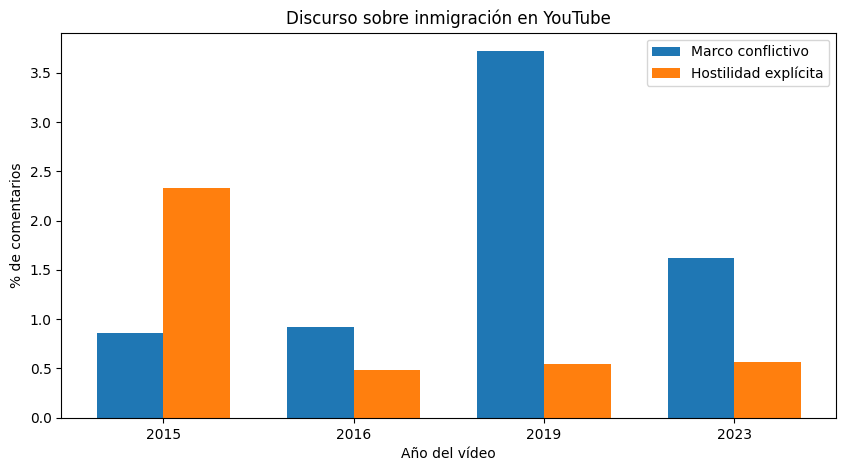

In [213]:
import matplotlib.pyplot as plt
import numpy as np

grafico_inm = pivot_porcentajes[
    pivot_porcentajes["tema"] == "inmigracion"
].copy()

x = np.arange(len(grafico_inm))

width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    grafico_inm["marco_conflictivo"],
    width,
    label="Marco conflictivo"
)

plt.bar(
    x + width/2,
    grafico_inm["hostilidad_explicita"],
    width,
    label="Hostilidad explícita"
)

plt.xticks(
    x,
    grafico_inm["año_video"]
)

plt.ylabel("% de comentarios")
plt.xlabel("Año del vídeo")

plt.title(
    "Discurso sobre inmigración en YouTube"
)

plt.legend()

plt.show()

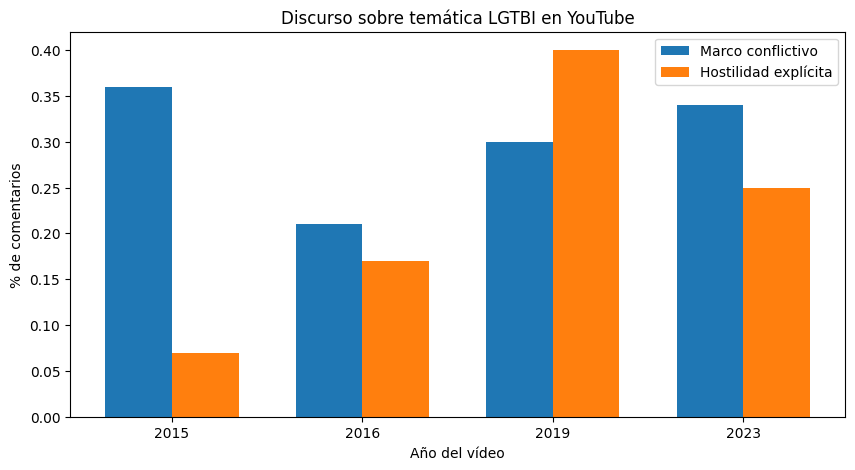

In [214]:
import matplotlib.pyplot as plt
import numpy as np

grafico_lgtbi = pivot_porcentajes[
    pivot_porcentajes["tema"] == "lgtbi"
].copy()

x = np.arange(len(grafico_lgtbi))

width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    grafico_lgtbi["marco_conflictivo"],
    width,
    label="Marco conflictivo"
)

plt.bar(
    x + width/2,
    grafico_lgtbi["hostilidad_explicita"],
    width,
    label="Hostilidad explícita"
)

plt.xticks(
    x,
    grafico_lgtbi["año_video"]
)

plt.ylabel("% de comentarios")
plt.xlabel("Año del vídeo")

plt.title(
    "Discurso sobre temática LGTBI en YouTube"
)

plt.legend()

plt.show()

In [215]:
resumen_mencion = (
    df_rrss
    .groupby(["tema", "año_video"])
    .agg(
        total_comentarios=("texto", "size"),
        comentarios_con_mencion=(
            "nivel_discurso",
            lambda x: (x != "sin_mencion").sum()
        )
    )
    .reset_index()
)

resumen_mencion["pct_con_mencion"] = (
    resumen_mencion["comentarios_con_mencion"]
    / resumen_mencion["total_comentarios"]
    * 100
).round(2)

resumen_mencion

,tema,año_video,total_comentarios,comentarios_con_mencion,pct_con_mencion
0,inmigracion,2015,816,252,30.88
1,inmigracion,2016,2073,203,9.79
2,inmigracion,2019,20150,2237,11.10
3,inmigracion,2023,7430,883,11.88
4,lgtbi,2015,2758,318,11.53
5,lgtbi,2016,4765,821,17.23
6,lgtbi,2019,5751,570,9.91
7,lgtbi,2023,5544,748,13.49


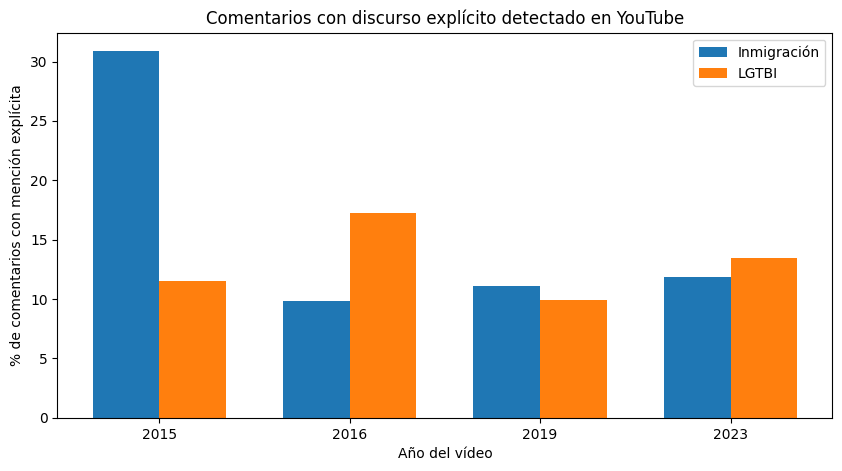

In [216]:
import matplotlib.pyplot as plt
import numpy as np

grafico_mencion = resumen_mencion.copy()

años = sorted(grafico_mencion["año_video"].unique())
x = np.arange(len(años))
width = 0.35

inm = (
    grafico_mencion[grafico_mencion["tema"] == "inmigracion"]
    .set_index("año_video")
    .reindex(años)
)

lgtbi = (
    grafico_mencion[grafico_mencion["tema"] == "lgtbi"]
    .set_index("año_video")
    .reindex(años)
)

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    inm["pct_con_mencion"],
    width,
    label="Inmigración"
)

plt.bar(
    x + width/2,
    lgtbi["pct_con_mencion"],
    width,
    label="LGTBI"
)

plt.xticks(x, años)

plt.xlabel("Año del vídeo")
plt.ylabel("% de comentarios con mención explícita")

plt.title(
    "Comentarios con discurso explícito detectado en YouTube"
)

plt.legend()
plt.show()

In [217]:
resumen_final = (
    pivot_porcentajes[
        [
            "tema",
            "año_video",
            "marco_conflictivo",
            "hostilidad_explicita"
        ]
    ]
)

resumen_final

nivel_discurso,tema,año_video,marco_conflictivo,hostilidad_explicita
0,inmigracion,2015,0.86,2.33
1,inmigracion,2016,0.92,0.48
2,inmigracion,2019,3.72,0.54
3,inmigracion,2023,1.62,0.57
4,lgtbi,2015,0.36,0.07
5,lgtbi,2016,0.21,0.17
6,lgtbi,2019,0.30,0.40
7,lgtbi,2023,0.34,0.25


In [218]:
resumen_final.to_csv(
    RUTA_PROCESADOS / "youtube_resultados_principales.csv",
    index=False,
    encoding="utf-8-sig"
)

# Integramos Youtube a elecciones por año

## 1. Preparar YouTube en formato ancho

In [219]:
youtube_integracion = pivot_porcentajes[
    [
        "tema",
        "año_video",
        "marco_conflictivo",
        "hostilidad_explicita",
        "neutro",
        "sin_mencion",
        "violencia_discriminacion"
    ]
].copy()

In [220]:
youtube_integracion = youtube_integracion.pivot(
    index="año_video",
    columns="tema",
    values=[
        "marco_conflictivo",
        "hostilidad_explicita",
        "neutro",
        "sin_mencion",
        "violencia_discriminacion"
    ]
)

## 2. Aplanar los nombres de las columnas

In [221]:
youtube_integracion.columns = [
    f"youtube_{nivel}_{tema}"
    for nivel, tema in youtube_integracion.columns
]

youtube_integracion = (
    youtube_integracion
    .reset_index()
    .rename(columns={"año_video": "año"})
)

youtube_integracion

,año,youtube_marco_conflictivo_inmigracion,youtube_marco_conflictivo_lgtbi,youtube_hostilidad_explicita_inmigracion,youtube_hostilidad_explicita_lgtbi,youtube_neutro_inmigracion,youtube_neutro_lgtbi,youtube_sin_mencion_inmigracion,youtube_sin_mencion_lgtbi,youtube_violencia_discriminacion_inmigracion,youtube_violencia_discriminacion_lgtbi
0,2015,0.86,0.36,2.33,0.07,27.70,9.28,69.12,88.47,0.0,1.81
1,2016,0.92,0.21,0.48,0.17,8.39,15.38,90.21,82.77,0.0,1.47
2,2019,3.72,0.30,0.54,0.40,6.84,8.62,88.90,90.09,0.0,0.59
3,2023,1.62,0.34,0.57,0.25,9.70,12.32,88.12,86.51,0.0,0.58


## 3. Integrarlo con elecciones_nacional

In [ ]:
for archivo in RUTA_TABLAS_INTEGRADO.glob("*.csv"):
    print(archivo.name)

distribucion_lgtbifobia.csv
distribucion_xenofobia.csv
elecciones_nacional.csv
prensa_elecciones_integrado.csv
prensa_final.csv


In [ ]:
df_integrado = pd.read_csv(
    RUTA_TABLAS_INTEGRADO
    / "prensa_elecciones_integrado.csv"
)

df_integrado.shape

(4, 19)

In [225]:
df_integrado["año"]

0    2015
1    2016
2    2019
3    2023
Name: año, dtype: int64

In [226]:
# ==================================================
# PREPARAR YOUTUBE PARA INTEGRACIÓN
# ==================================================

youtube_integracion = pivot_porcentajes[
    [
        "tema",
        "año_video",
        "marco_conflictivo",
        "hostilidad_explicita",
        "neutro",
        "sin_mencion",
        "violencia_discriminacion"
    ]
].copy()

youtube_integracion = youtube_integracion.pivot(
    index="año_video",
    columns="tema",
    values=[
        "marco_conflictivo",
        "hostilidad_explicita",
        "neutro",
        "sin_mencion",
        "violencia_discriminacion"
    ]
)

youtube_integracion.columns = [
    f"youtube_{nivel}_{tema}"
    for nivel, tema in youtube_integracion.columns
]

youtube_integracion = (
    youtube_integracion
    .reset_index()
    .rename(columns={"año_video": "año"})
)

youtube_integracion

,año,youtube_marco_conflictivo_inmigracion,youtube_marco_conflictivo_lgtbi,youtube_hostilidad_explicita_inmigracion,youtube_hostilidad_explicita_lgtbi,youtube_neutro_inmigracion,youtube_neutro_lgtbi,youtube_sin_mencion_inmigracion,youtube_sin_mencion_lgtbi,youtube_violencia_discriminacion_inmigracion,youtube_violencia_discriminacion_lgtbi
0,2015,0.86,0.36,2.33,0.07,27.70,9.28,69.12,88.47,0.0,1.81
1,2016,0.92,0.21,0.48,0.17,8.39,15.38,90.21,82.77,0.0,1.47
2,2019,3.72,0.30,0.54,0.40,6.84,8.62,88.90,90.09,0.0,0.59
3,2023,1.62,0.34,0.57,0.25,9.70,12.32,88.12,86.51,0.0,0.58


In [227]:
# ==================================================
# INTEGRAR PRENSA + ELECCIONES + YOUTUBE
# ==================================================

df_integrado_final = df_integrado.merge(
    youtube_integracion,
    on="año",
    how="left"
)

df_integrado_final.shape

(4, 29)

In [228]:
df_integrado_final[
    [
        "año",
        "pct_Extrema derecha",
        "marco_conflictivo_xeno",
        "hostilidad_explicita_xeno",
        "youtube_marco_conflictivo_inmigracion",
        "youtube_hostilidad_explicita_inmigracion",
        "youtube_marco_conflictivo_lgtbi",
        "youtube_hostilidad_explicita_lgtbi"
    ]
]

,año,pct_Extrema derecha,marco_conflictivo_xeno,hostilidad_explicita_xeno,youtube_marco_conflictivo_inmigracion,youtube_hostilidad_explicita_inmigracion,youtube_marco_conflictivo_lgtbi,youtube_hostilidad_explicita_lgtbi
0,2015,0.263419,18.59,4.65,0.86,2.33,0.36,0.07
1,2016,0.240119,14.61,5.31,0.92,0.48,0.21,0.17
2,2019,12.762429,19.54,5.68,3.72,0.54,0.30,0.40
3,2023,12.576779,31.22,8.32,1.62,0.57,0.34,0.25


In [ ]:
df_integrado_final.to_csv(
    RUTA_TABLAS_INTEGRADO
    / "integrado_nacional_prensa_youtube.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Integración completada")

Integración completada


## Relación porcentaje extrama derecha y marco_conflictivo_xeno, youtube_marco_conflictivo_inmigracion 


In [230]:
corr = df_integrado_final.select_dtypes(
    include="number"
).corr()

corr.round(2)

,año,pct_Centro,pct_Derecha,pct_Extrema derecha,pct_Izquierda,paro_medio,pct_inmigrantes,Gini,delitos_por_100k,hostilidad_explicita_xeno,...,youtube_marco_conflictivo_inmigracion,youtube_marco_conflictivo_lgtbi,youtube_hostilidad_explicita_inmigracion,youtube_hostilidad_explicita_lgtbi,youtube_neutro_inmigracion,youtube_neutro_lgtbi,youtube_sin_mencion_inmigracion,youtube_sin_mencion_lgtbi,youtube_violencia_discriminacion_inmigracion,youtube_violencia_discriminacion_lgtbi
año,1.00,0.97,-0.81,0.88,-0.98,-0.97,0.97,-0.99,0.95,0.96,...,0.39,0.28,-0.57,0.58,-0.55,0.01,0.53,0.14,NaN,-0.89
pct_Centro,0.97,1.00,-0.92,0.96,-0.97,-0.99,0.90,-0.99,0.85,0.88,...,0.58,0.29,-0.58,0.73,-0.59,-0.16,0.55,0.31,NaN,-0.96
pct_Derecha,-0.81,-0.92,1.00,-0.99,0.79,0.88,-0.69,0.87,-0.59,-0.62,...,-0.82,-0.40,0.42,-0.84,0.47,0.50,-0.39,-0.63,NaN,0.93
pct_Extrema derecha,0.88,0.96,-0.99,1.00,-0.87,-0.94,0.76,-0.93,0.69,0.72,...,0.77,0.30,-0.54,0.85,-0.58,-0.35,0.51,0.50,NaN,-0.97
pct_Izquierda,-0.98,-0.97,0.79,-0.87,1.00,0.98,-0.92,0.98,-0.91,-0.94,...,-0.43,-0.11,0.71,-0.66,0.68,-0.11,-0.67,-0.05,NaN,0.92
paro_medio,-0.97,-0.99,0.88,-0.94,0.98,1.00,-0.87,0.98,-0.84,-0.88,...,-0.58,-0.14,0.70,-0.77,0.70,0.04,-0.67,-0.19,NaN,0.97
pct_inmigrantes,0.97,0.90,-0.69,0.76,-0.92,-0.87,1.00,-0.94,0.99,0.98,...,0.18,0.41,-0.39,0.36,-0.35,0.03,0.35,0.09,NaN,-0.75
Gini,-0.99,-0.99,0.87,-0.93,0.98,0.98,-0.94,1.00,-0.91,-0.93,...,-0.48,-0.30,0.57,-0.65,0.56,0.08,-0.53,-0.23,NaN,0.93
delitos_por_100k,0.95,0.85,-0.59,0.69,-0.91,-0.84,0.99,-0.91,1.00,1.00,...,0.08,0.30,-0.44,0.30,-0.39,0.18,0.41,-0.06,NaN,-0.70
hostilidad_explicita_xeno,0.96,0.88,-0.62,0.72,-0.94,-0.88,0.98,-0.93,1.00,1.00,...,0.13,0.23,-0.53,0.37,-0.47,0.21,0.49,-0.08,NaN,-0.75


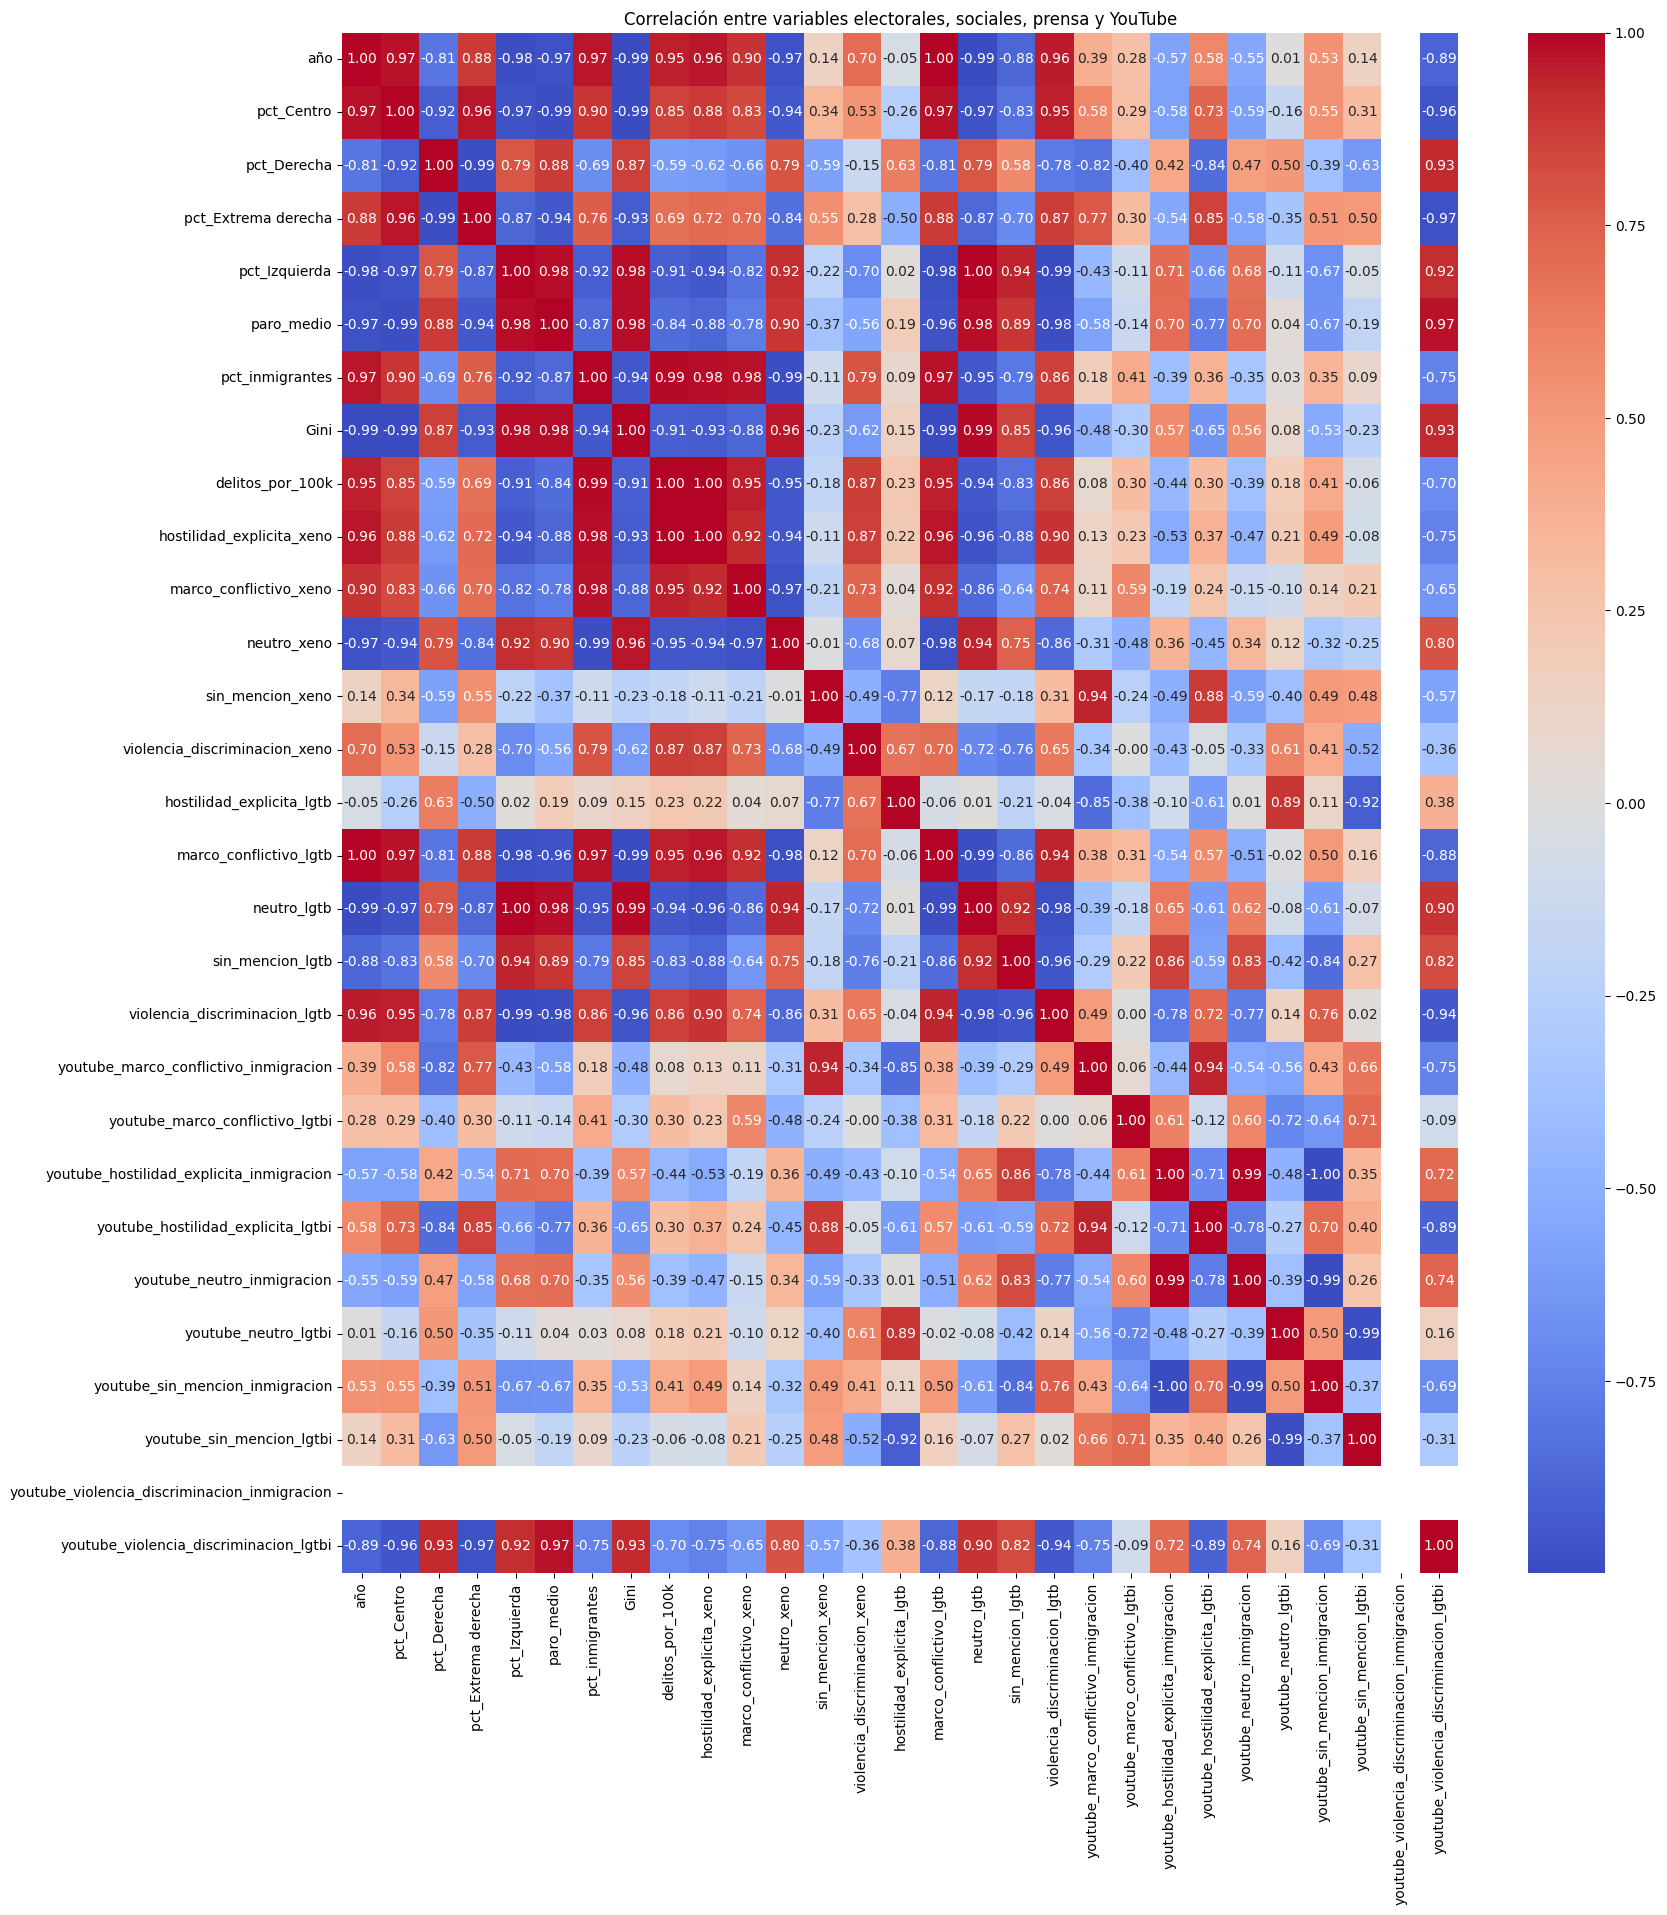

In [231]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,20))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlación entre variables electorales, sociales, prensa y YouTube"
)

plt.show()

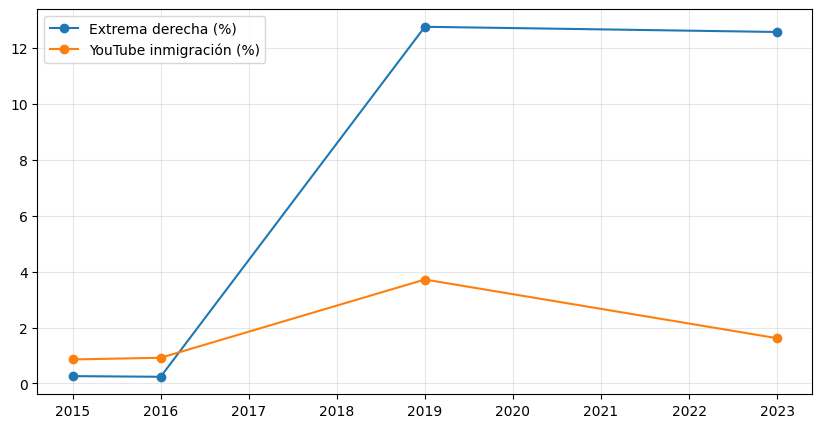

In [232]:
plt.figure(figsize=(10,5))

plt.plot(
    df_integrado_final["año"],
    df_integrado_final["pct_Extrema derecha"],
    marker="o",
    label="Extrema derecha (%)"
)

plt.plot(
    df_integrado_final["año"],
    df_integrado_final["youtube_marco_conflictivo_inmigracion"],
    marker="o",
    label="YouTube inmigración (%)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
df_integrado_final.to_csv(
    RUTA_TABLAS_INTEGRADO
    / "integrado_prensa_youtube_v1.csv",
    index=False,
    encoding="utf-8-sig"
)

In [236]:
print(df_2019_inm.shape)

(20151, 10)


In [ ]:
df_rrss[
    (df_rrss["tema"] == "inmigracion")
    &
    (df_rrss["año_video"] == 2019)
]["nivel_discurso"].value_counts()